In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


In [ ]:

# 1. Generate Synthetic Dataset


np.random.seed(42)
n_samples = 5000

contract_type = np.random.choice([0, 1, 2], p=[0.5, 0.3, 0.2], size=n_samples)
tenure = np.random.randint(0, 73, size=n_samples)
monthly_charges = np.random.uniform(20, 120, size=n_samples)

churn_prob = (
    0.4 * (contract_type == 0) +
    0.3 * np.clip(1 - (tenure / 72), 0, 1) +
    0.3 * ((monthly_charges - 20) / 100)
)

churn_prob += np.random.normal(0, 0.1, size=n_samples)

threshold = np.percentile(churn_prob, 75)
churn = (churn_prob > threshold).astype(int)

df = pd.DataFrame({
    "Contract": contract_type,
    "Tenure": tenure,
    "MonthlyCharges": monthly_charges,
    "Churn": churn
})

print("Class Distribution:")
print(df["Churn"].value_counts(normalize=True))
print("-" * 50)


Class Distribution:
Churn
0    0.75
1    0.25
Name: proportion, dtype: float64
--------------------------------------------------


In [ ]:
# 2. Prepare Data

X = df[["Contract", "Tenure", "MonthlyCharges"]]
y = df["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 3. Train Model

model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
# 4. Evaluation

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

print("Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("-" * 50)


Model Performance:
Accuracy: 0.8720
F1 Score: 0.7785
ROC-AUC: 0.9503

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       750
           1       0.69      0.90      0.78       250

    accuracy                           0.87      1000
   macro avg       0.82      0.88      0.84      1000
weighted avg       0.89      0.87      0.88      1000

--------------------------------------------------


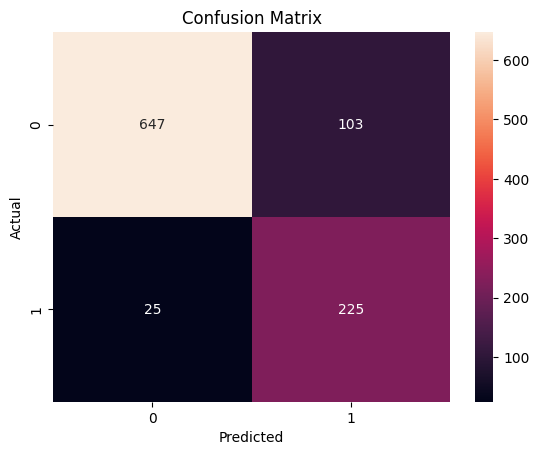

In [ ]:
# 5. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

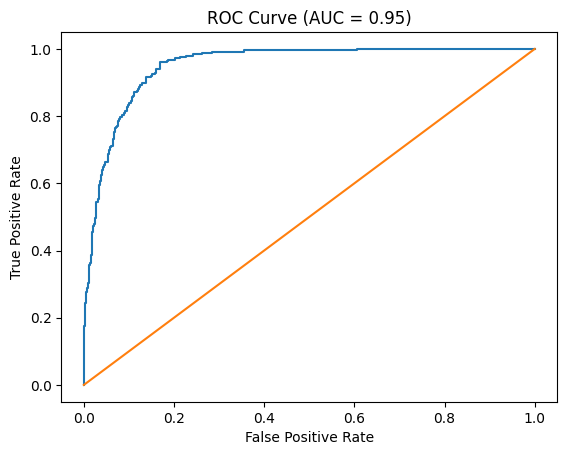

In [ ]:
# 6. ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


Feature Importance:
          Feature    Weight
0        Contract -4.244763
2  MonthlyCharges  1.477989
1          Tenure -1.465813


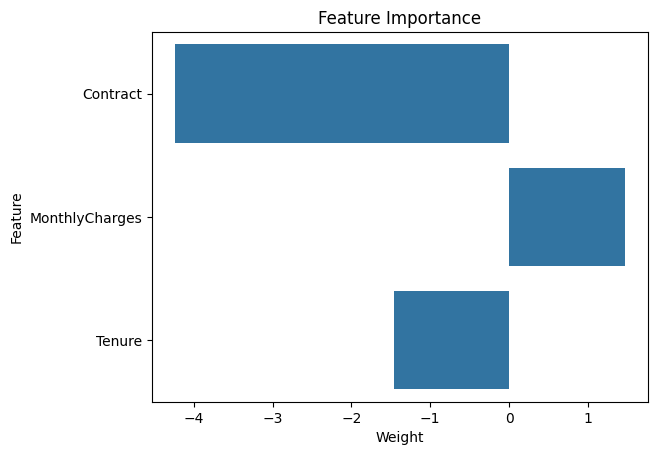

In [ ]:
# 7. Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Weight": model.coef_[0]
}).sort_values(by="Weight", key=abs, ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure()
sns.barplot(
    x=feature_importance["Weight"],
    y=feature_importance["Feature"]
)
plt.title("Feature Importance")
plt.show()

In [ ]:
# 8. Business Insight

print("\nBusiness Insight:")
print("Customers on month-to-month contracts and with higher monthly charges")
print("show higher churn probability. Target them with retention campaigns.")


Business Insight:
Customers on month-to-month contracts and with higher monthly charges
show higher churn probability. Target them with retention campaigns.
